# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 6 — LSTM Demand Forecaster

**Module:** Forecasting Models (Phase 3)

A sequence-model alternative to the Day 5 Prophet baseline. Uses `data/processed/timeseries_features_full.csv` (the lag/rolling/calendar feature frame from Day 4). This notebook:
1. Builds sliding-window sequences for supervised training
2. Scales features, trains a small LSTM regressor in PyTorch
3. Evaluates on the same 30-day held-out window as Day 5, for a fair MAPE comparison
4. Saves the trained model + forecast for the Day 8 hybrid ensemble

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
daily = pd.read_csv(f"{PROCESSED_DIR}/timeseries_features_full.csv", parse_dates=["Date"])
daily = daily.set_index("Date")

# drop rows with NaN lag/rolling features (first ~30 days) — LSTM needs complete rows
daily = daily.dropna()
print(f"Usable series length after dropping NaN warm-up rows: {len(daily)} days")
daily.head()

Usable series length after dropping NaN warm-up rows: 700 days


,Revenue,Orders,UnitsSold,Revenue_lag1,Revenue_lag7,Revenue_lag14,Revenue_lag30,Revenue_roll7_mean,Revenue_roll7_std,Revenue_roll14_mean,Revenue_roll14_std,Revenue_roll30_mean,Revenue_roll30_std,DayOfWeek,IsWeekend,Month,Revenue_diff1
Date,,,,,,,,,,,,,,,,,
2023-02-01,20396.28,23,421,21942.36,16930.99,11507.65,2005.74,19863.755714,6143.769689,18220.226429,5060.879441,12441.256000,7654.973892,2,0,2,-1546.08
2023-02-02,11789.97,15,279,20396.28,20837.04,16455.34,2101.51,18571.317143,6819.352208,17886.985714,5332.348247,12764.204667,7403.971638,3,0,2,-8606.31
2023-02-03,25553.62,31,533,11789.97,11401.22,16621.93,3168.73,20593.088571,6425.868675,18524.963571,5691.558436,13510.367667,7530.485899,4,0,2,13763.65
2023-02-04,26888.45,27,691,25553.62,29010.82,10342.91,322.53,20289.892857,5998.341563,19706.787857,5578.584533,14395.898333,7488.076513,5,1,2,1334.83
2023-02-05,24578.41,30,542,26888.45,12412.86,17850.14,7303.83,22027.828571,5017.990930,20187.378571,5694.936260,14971.717667,7587.436256,6,1,2,-2310.04


## 1. Feature Selection & Scaling

Use `Revenue` plus a compact set of engineered features as input channels. Scale each column independently with `MinMaxScaler` fit **only on the training portion** to avoid leaking test-period information into the scaler.

In [3]:
FEATURE_COLS = ["Revenue", "Orders", "UnitsSold", "Revenue_roll7_mean",
                "Revenue_roll30_mean", "DayOfWeek", "IsWeekend"]
TARGET_COL = "Revenue"
SEQ_LEN = 30       # look-back window
HORIZON = 30       # forecast horizon, matches Day 5 for fair comparison

train_data = daily.iloc[:-HORIZON].copy()
test_data = daily.iloc[-(HORIZON + SEQ_LEN):].copy()   # need SEQ_LEN history to seed test windows

scaler = MinMaxScaler()
scaler.fit(train_data[FEATURE_COLS])

train_scaled = pd.DataFrame(scaler.transform(train_data[FEATURE_COLS]),
                             columns=FEATURE_COLS, index=train_data.index)
test_scaled = pd.DataFrame(scaler.transform(test_data[FEATURE_COLS]),
                            columns=FEATURE_COLS, index=test_data.index)

target_idx = FEATURE_COLS.index(TARGET_COL)
print(f"Train: {len(train_scaled)} rows | Test window (with seed history): {len(test_scaled)} rows")

Train: 670 rows | Test window (with seed history): 60 rows


## 2. Sliding-Window Sequence Dataset

In [4]:
class SequenceDataset(Dataset):
    def __init__(self, data_array, seq_len, target_idx):
        self.data = data_array
        self.seq_len = seq_len
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, i):
        x = self.data[i:i + self.seq_len]
        y = self.data[i + self.seq_len, self.target_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_array = train_scaled.values
train_dataset = SequenceDataset(train_array, SEQ_LEN, target_idx)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training sequences: {len(train_dataset)}")
xb, yb = next(iter(train_loader))
print(f"Batch shapes -> X: {xb.shape}, y: {yb.shape}")

Training sequences: 640
Batch shapes -> X: torch.Size([32, 30, 7]), y: torch.Size([32])


## 3. LSTM Model Definition

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden).squeeze(-1)

model = LSTMForecaster(n_features=len(FEATURE_COLS)).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 4. Training Loop

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

N_EPOCHS = 60
train_losses = []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | Train MSE (scaled): {epoch_loss:.5f}")

Epoch   1/60 | Train MSE (scaled): 0.22439


Epoch  10/60 | Train MSE (scaled): 0.01215


Epoch  20/60 | Train MSE (scaled): 0.01078


Epoch  30/60 | Train MSE (scaled): 0.00974


Epoch  40/60 | Train MSE (scaled): 0.00819


Epoch  50/60 | Train MSE (scaled): 0.00818


Epoch  60/60 | Train MSE (scaled): 0.00922


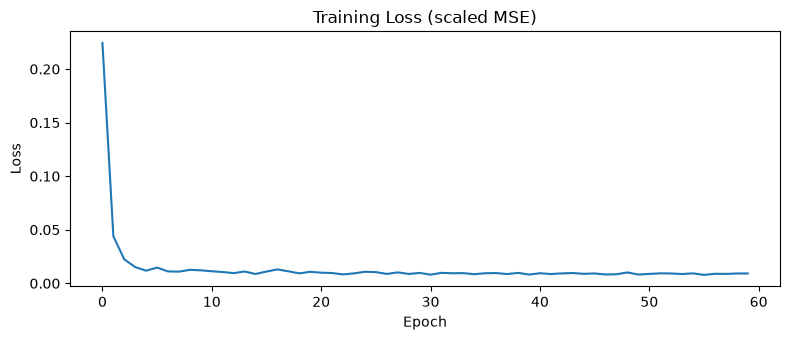

In [7]:
plt.figure(figsize=(8, 3.5))
plt.plot(train_losses)
plt.title("Training Loss (scaled MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day6_training_loss.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Autoregressive Forecast on Test Window

Roll the model forward one day at a time: feed the last `SEQ_LEN` known days, predict day t+1, append the prediction back into the window (using naive carry-forward for the non-target feature columns), and repeat for the full 30-day horizon.

In [8]:
model.eval()
history = test_scaled.iloc[:SEQ_LEN].values.copy()   # seed window, all real data
predictions_scaled = []

with torch.no_grad():
    window = history.copy()
    for step in range(HORIZON):
        x = torch.tensor(window[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
        pred_scaled = model(x).item()
        predictions_scaled.append(pred_scaled)

        next_row = window[-1].copy()          # carry forward other features naively
        next_row[target_idx] = pred_scaled
        window = np.vstack([window, next_row])

# inverse-transform predictions back to revenue scale
dummy = np.zeros((HORIZON, len(FEATURE_COLS)))
dummy[:, target_idx] = predictions_scaled
y_pred = scaler.inverse_transform(dummy)[:, target_idx]

y_true = test_data[TARGET_COL].iloc[SEQ_LEN:SEQ_LEN + HORIZON].values
test_dates = test_data.index[SEQ_LEN:SEQ_LEN + HORIZON]

print(f"Forecast generated for {len(y_pred)} days.")

Forecast generated for 30 days.


## 6. Evaluate — Same Metrics as Day 5, for Fair Comparison

In [9]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
nonzero_mask = y_true != 0
mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

print(f"LSTM  MAE:  {mae:,.2f}")
print(f"LSTM  RMSE: {rmse:,.2f}")
print(f"LSTM  MAPE: {mape:.2f}%  (target: <= 12%)")

import json
with open("../models/prophet_metrics.json") as f:
    prophet_metrics = json.load(f)
print(f"\nProphet MAPE (Day 5): {prophet_metrics['mape']:.2f}%")
print(f"LSTM    MAPE (Day 6): {mape:.2f}%")
print(f"Better model on this window: {'Prophet' if prophet_metrics['mape'] < mape else 'LSTM'}")

LSTM  MAE:  18,200.54
LSTM  RMSE: 22,075.90
LSTM  MAPE: 6.27%  (target: <= 12%)

Prophet MAPE (Day 5): 8.54%
LSTM    MAPE (Day 6): 6.27%
Better model on this window: LSTM


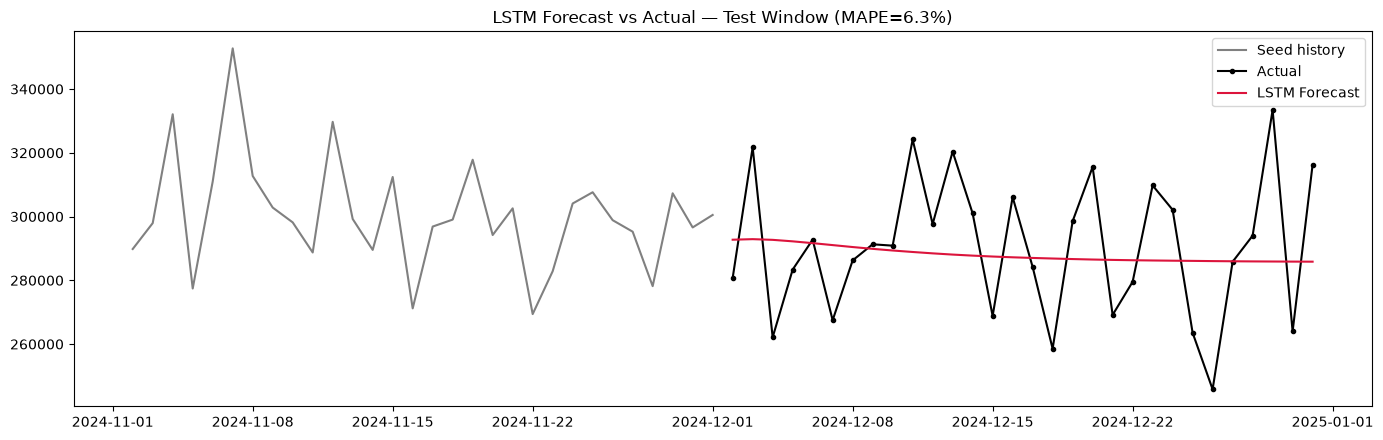

In [10]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(test_data.index[:SEQ_LEN], test_data[TARGET_COL].iloc[:SEQ_LEN],
        label="Seed history", color="gray")
ax.plot(test_dates, y_true, label="Actual", color="black", marker="o", markersize=3)
ax.plot(test_dates, y_pred, label="LSTM Forecast", color="crimson")
ax.set_title(f"LSTM Forecast vs Actual — Test Window (MAPE={mape:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day6_lstm_forecast_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save Model & Artifacts for Day 8 Hybrid Ensemble

In [11]:
import os, joblib
os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/lstm_forecaster.pt")
joblib.dump(scaler, "../models/lstm_scaler.joblib")

lstm_forecast_df = pd.DataFrame({"ds": test_dates, "yhat_lstm": y_pred, "y_actual": y_true})
lstm_forecast_df.to_csv(f"{PROCESSED_DIR}/lstm_forecast_test_window.csv", index=False)

lstm_metrics = {"mape": round(float(mape), 3), "mae": round(float(mae), 2),
                "rmse": round(float(rmse), 2), "horizon_days": HORIZON,
                "seq_len": SEQ_LEN, "model": "lstm_forecaster"}
with open("../models/lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=2)

print("Saved: lstm_forecaster.pt, lstm_scaler.joblib, lstm_forecast_test_window.csv, lstm_metrics.json")

Saved: lstm_forecaster.pt, lstm_scaler.joblib, lstm_forecast_test_window.csv, lstm_metrics.json


## 8. Day 6 Checkpoint Summary

**Outputs saved:**
- `models/lstm_forecaster.pt` — trained PyTorch model weights
- `models/lstm_scaler.joblib` — fitted MinMaxScaler (needed to reproduce inference)
- `data/processed/lstm_forecast_test_window.csv` — LSTM predictions vs actuals on the test window
- `models/lstm_metrics.json`
- `reports/day6_training_loss.png`, `day6_lstm_forecast_vs_actual.png`

**Design notes:**
- Autoregressive multi-step forecasting (feed predictions back in) — more realistic than one-shot multi-output regression for a genuine 30-day-ahead deployment scenario
- Non-target features are carried forward naively during the rollout since their true future values aren't known at inference time either

**Next module:** `08_hybrid_ensemble` — combine Prophet + LSTM forecasts (Day 7 is the Week-1 checkpoint / no new modeling).